# Page View Time Series Visualizer

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters

register_matplotlib_converters()

# 1. Import data
df = pd.read_csv('/fcc-forum-pageviews.csv', parse_dates=['date'], index_col='date')

# 2. Clean data
df = df[
    (df['value'] >= df['value'].quantile(0.025)) &
    (df['value'] <= df['value'].quantile(0.975))
]

# 3. Draw Line Plot
def draw_line_plot():
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(df.index, df['value'], color='red', linewidth=1)

    # Set title and labels
    ax.set_title('Daily freeCodeCamp Forum Page Views 5/2016-12/2019', fontsize=16)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Page Views', fontsize=12)

    # Save image and return figure
    fig.savefig('line_plot.png')
    return fig

# 4. Draw Bar Plot
def draw_bar_plot():
    # Copy and modify data for monthly bar plot
    df_bar = df.copy()
    df_bar['year'] = df_bar.index.year
    df_bar['month'] = df_bar.index.month
    df_bar = df_bar.groupby(['year', 'month'])['value'].mean().unstack()

    # Create figure
    fig = df_bar.plot(kind='bar', figsize=(12, 6), legend=True).figure

    # Set title, labels, and legend
    plt.xlabel('Years', fontsize=12)
    plt.ylabel('Average Page Views', fontsize=12)
    plt.legend(
        title='Months',
        labels=[
            'January', 'February', 'March', 'April', 'May', 'June',
            'July', 'August', 'September', 'October', 'November', 'December'
        ]
    )

    # Save image and return figure
    fig.savefig('bar_plot.png')
    return fig

# 5. Draw Box Plot
def draw_box_plot():
    # Prepare data for box plots
    df_box = df.copy()
    df_box.reset_index(inplace=True)
    df_box['year'] = df_box['date'].dt.year
    df_box['month'] = df_box['date'].dt.strftime('%b')
    df_box['month_num'] = df_box['date'].dt.month
    df_box = df_box.sort_values('month_num')

    # Create figure and draw box plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Year-wise Box Plot
    sns.boxplot(
        x='year', y='value', data=df_box, ax=axes[0]
    ).set(title='Year-wise Box Plot (Trend)', xlabel='Year', ylabel='Page Views')

    # Month-wise Box Plot
    sns.boxplot(
        x='month', y='value', data=df_box, ax=axes[1]
    ).set(title='Month-wise Box Plot (Seasonality)', xlabel='Month', ylabel='Page Views')

    # Save image and return figure
    fig.savefig('box_plot.png')
    return fig


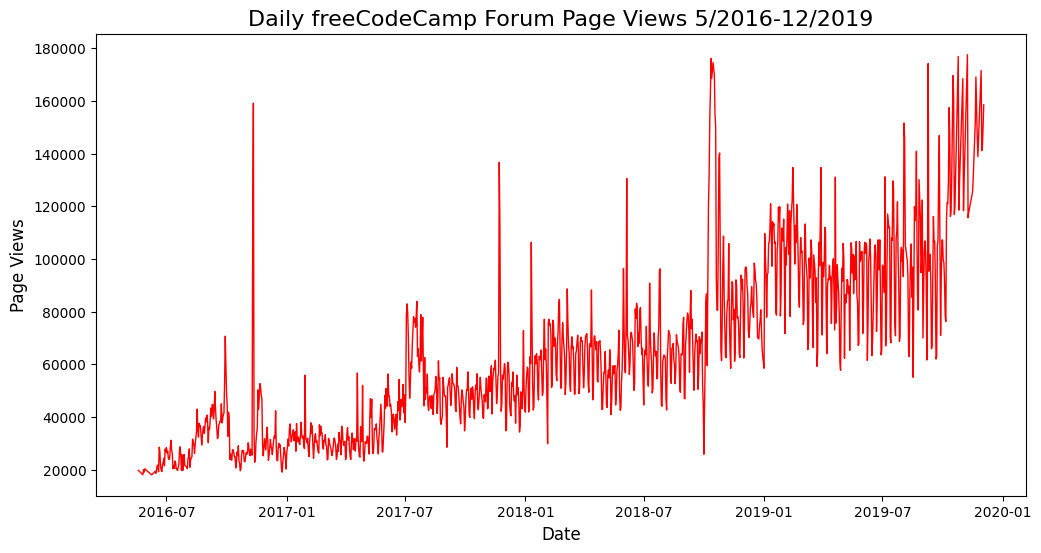

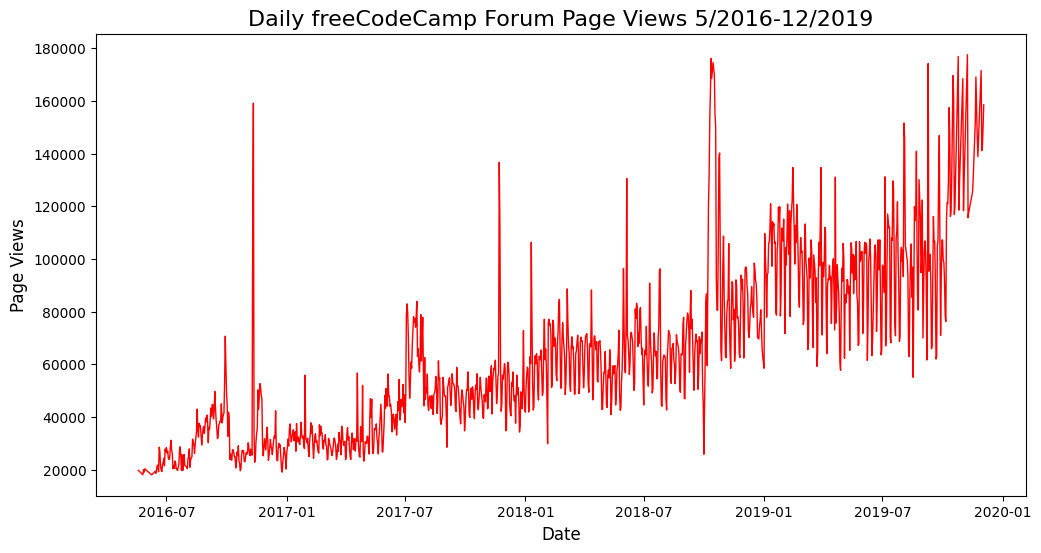

In [ ]:
draw_line_plot()

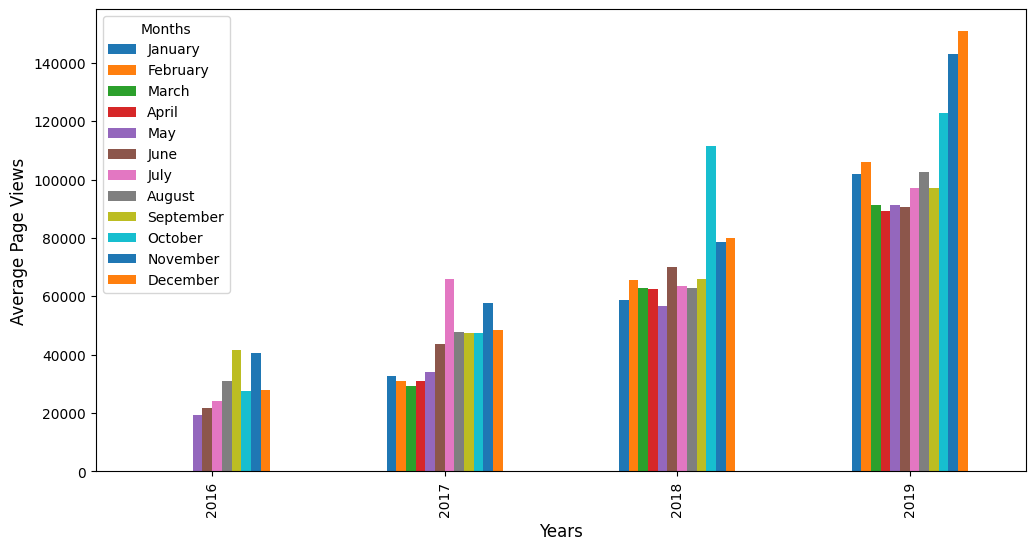

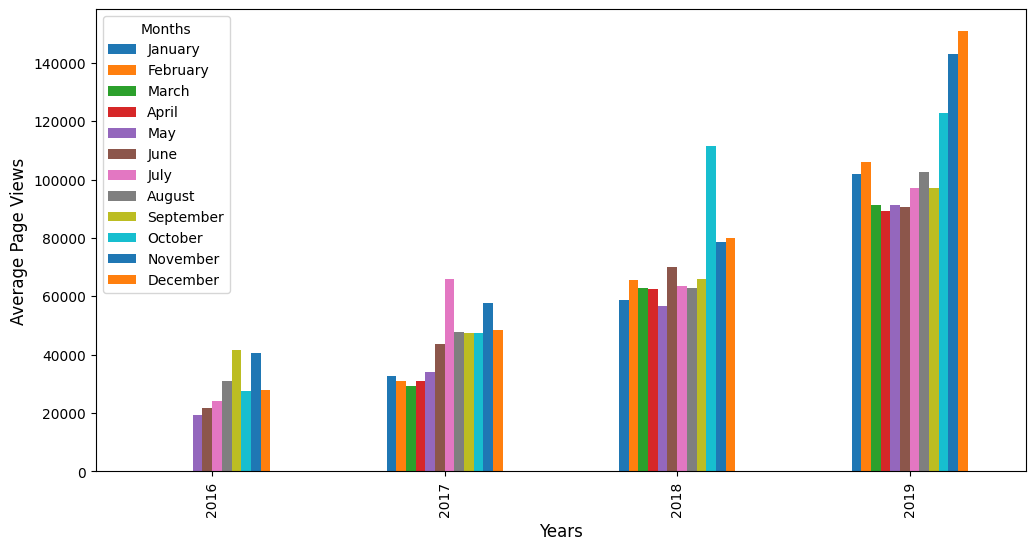

In [ ]:
draw_bar_plot()

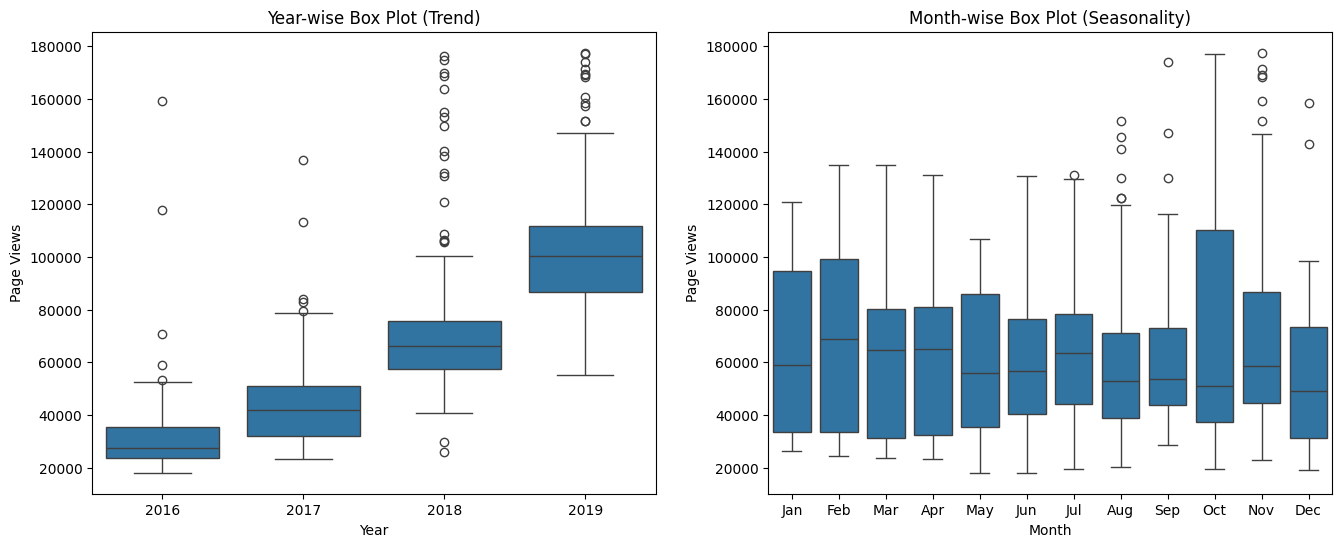

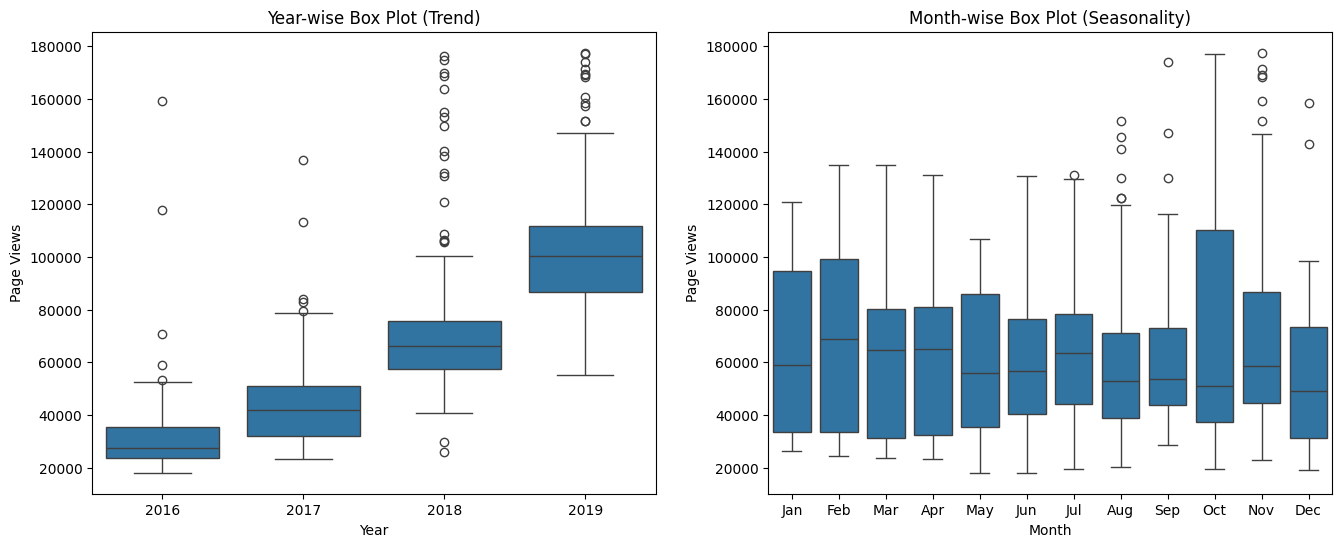

In [ ]:
draw_box_plot()